# CROCUS Data Access

This notebook demonstrates how to access sensor data from the CROCUS 
(Community Research on Climate and Urban Science) network of Waggle/Sage
nodes deployed across Chicagoland.

The best way to check current sensor availability and recent data is through 
the Sage portal:
  - All nodes: https://portal.sagecontinuum.org/nodes
  - NEIU node:  https://portal.sagecontinuum.org/nodes/W08D

Further documentation:
  - Sage Data Client: https://github.com/sagecontinuum/sage-data-client
  - CROCUS Instrument Cookbooks: https://crocus-urban.github.io/instrument-cookbooks/
  - CROCUS Data on ESS-DIVE: https://data.ess-dive.lbl.gov/portals/crocus/Data

## Why sage_utils?

This notebook makes heavy use of the local package sage_utils. The Sage Data Client returns 
data in long format --- one row per measurement --- with variable names, metadata, and 
fill values that require consistent handling. The functions in `sage_utils.py` handle this 
wrangling automatically, returning clean wide-format DataFrames with intuitive column names, 
missing values replaced with NaN, and data resampled to a consistent 5-minute resolution regardless of 
the underlying sampling rate.

This makes it straightforward to load any sensor type with a single function 
call and compare data across years and sites without worrying about format 
differences.

## Network Notes

- All CROCUS WXT and AQT nodes were offline approximately December 2025 -- 
  March 2026 during a network-wide maintenance period.
- The 5-minute averaging plugin was deployed across all nodes when they came 
  back online in April 2026. Historical WXT data prior to this transition was 
  sampled at >1Hz; historical AQT data was at 1-minute intervals.
- All data returned by the query functions is resampled to 5-minute means for 
  consistency across years.

In [1]:
# Standard library
import datetime as dt
import ssl

# Third party
import matplotlib.pyplot as plt
import pandas as pd
import sage_data_client

# Local
import importlib
import crocus_sites
importlib.reload(crocus_sites)
import sage_utils
importlib.reload(sage_utils)
from crocus_sites import (
    ALL_SITES,
    ATMOS, BIG, CCICS, CSU,
    HUM, NEIU, NU, SHEDD, UIC,
)
from sage_utils import (
    query_aqt, query_wxt,
    query_sapflow, query_mfr,
    last_n_hours,
)

ssl._create_default_https_context = ssl._create_unverified_context

## CROCUS Site Class

The `CROCUSSite` class in `crocus_sites.py` contains metadata for each CROCUS 
field site including full name, Sage/Waggle Virtual Sage Node ID (vsn), 
site abbreviation, geographic coordinates, and sensor availability flags.
Each site is a `CROCUSSite` instance accessible directly by name (e.g. `NEIU`, `CSU`).

To see all available sites:
```python
for site in ALL_SITES:
    print(f"{site.abbr:<8} {site.vsn}  {site.full_name}")
```

To select a site for querying throughout this notebook, set `SITE` to any 
site object from `ALL_SITES`:
```python
SITE = NEIU   # change this to CSU, BIG, NU etc. to query a different site
```

In [2]:
for site in ALL_SITES:
    print(f"{site.abbr:<8} {site.vsn}  {site.full_name}")

ATMOS    W0A4  Argonne Testbed for Multiscale Observational Science
BIG      W0A0  Blacks in Green (West Woodlawn)
CCICS    W08B  Carruthers Center for Inner City Studies — Bronzeville (NEIU satellite)
CSU      W08E  Chicago State University
HUM      W0A1  Humboldt Park
NEIU     W08D  Northeastern Illinois University
NU       W099  Northwestern University
SHEDD    W09E  Shedd Aquarium
UIC      W096  University of Illinois Chicago


In [3]:
# The sites listed above may be used to query throughout this notebook.
# Change the site name here to switch to a different CROCUS location.
SITE = NEIU
print(f"Querying: {SITE.full_name} ({SITE.vsn})")

Querying: Northeastern Illinois University (W08D)


## WXT

### Recent Data (Last N hours)

In [ ]:
# To see documentation for any function, type the function name followed by ?
# e.g.:
query_wxt?

In [4]:
start, end = last_n_hours(1)  # return(N) a (start,end) tuple for last N hours
wxt_last_hour = query_wxt(SITE.vsn,start,end)       
wxt_last_hour.head()

,humidity,pressure,temp,rain,wind_dir,wind_speed,vsn,sensor
timestamp,,,,,,,,
2026-05-24 20:25:00+00:00,63.023,993.619,21.330,38.19,82.279,2.110,W08D,vaisala-wxt536
2026-05-24 20:30:00+00:00,64.522,993.664,20.837,38.19,62.073,2.105,W08D,vaisala-wxt536
2026-05-24 20:35:00+00:00,64.732,993.676,20.888,38.19,75.441,1.344,W08D,vaisala-wxt536
2026-05-24 20:40:00+00:00,63.564,993.700,21.192,38.19,83.963,1.777,W08D,vaisala-wxt536
2026-05-24 20:45:00+00:00,65.200,993.700,20.600,38.19,221.000,0.400,W08D,vaisala-wxt536


In [ ]:
fig, ax1 = plt.subplots(figsize=(12, 4))


ax1.plot(wxt_last_hour.index, wxt_last_hour['temp'],
         marker='o', markersize=3, color='firebrick',
         label='Temperature (°C)')
ax1.set_ylabel('Temperature (°C)', color='firebrick')
ax1.tick_params(axis='y', labelcolor='firebrick')
ax1.set_xlabel('Time (UTC)')
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(wxt_last_hour.index, wxt_last_hour['wind_speed'],
         marker='o', markersize=3, color='steelblue', 
         label='Wind Speed (m/s)')
ax2.set_ylabel('Wind Speed (m/s)', color='steelblue')
ax2.tick_params(axis='y', labelcolor='steelblue')

ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
fig.suptitle(f'WXT — {SITE.abbr} ({SITE.vsn}) — Last Hour', fontsize=12)
fig.tight_layout()
plt.show()

## AQT

Several nodes have PM sensors which stopped functioning. That is reflected in the plots below.

In [ ]:
start, end = last_n_hours(1)
aqt_last_hour = query_aqt(SITE.vsn,start,end)       
aqt_last_hour.head()

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

ax1.plot(aqt_last_hour.index, aqt_last_hour['o3'],
         marker='o', markersize=3, label='O$_3$', color='darkgreen')
ax1.plot(aqt_last_hour.index, aqt_last_hour['no2'],
         marker='o', markersize=3, label='NO$_2$', color='darkblue')
ax1.set_ylabel('O$_3$, NO$_2$ (ppb)')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

ax2.plot(aqt_last_hour.index, aqt_last_hour['pm25'],
         marker='o', markersize=3, label='PM$_{25}$', color='#08306b')
ax2.set_ylabel('PM$_{25}$ (µg/m$^3$)')
ax2.set_xlabel('Time (UTC)')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

fig.suptitle(f'AQT — {SITE.abbr} ({SITE.vsn}) — Last Hour', fontsize=12)
fig.tight_layout()
plt.show()

## Data with Specified Date Range

In [ ]:
# This can take 1.5s to run
START = "2023-06-01"  # start is at the beginning of this day
END   = "2023-06-02"  # end is at the beginning of this day

df_aqt = query_aqt(SITE.vsn,START,END)

This takes ~7 minutes for 2023 data due to >1Hz historical sampling rate.

In [ ]:
# This can take 5-7 min to run.
df_wxt = query_wxt(SITE.vsn,START,END)

In [ ]:
print(f"df_aqt: {df_aqt.shape}, {df_aqt.memory_usage(deep=True).sum() / 1e6:.2f} MB")
print(f"df_wxt: {df_wxt.shape}, {df_wxt.memory_usage(deep=True).sum() / 1e6:.2f} MB")

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# --- Panel 1: Temperature and Humidity ---
ax1.plot(df_wxt.index, df_wxt['temp'],
         color='firebrick', linewidth=0.8, label='Temperature (°C)')
ax1.plot(df_wxt.index,
         df_wxt['temp'].rolling('60min', center=True).mean(),
         color='darkred', linewidth=2, label='Temp (1hr mean)')
ax1.set_ylabel('Temperature (°C)', color='firebrick')
ax1.tick_params(axis='y', labelcolor='firebrick')
ax1.grid(True, alpha=0.3)

ax1b = ax1.twinx()
ax1b.plot(df_wxt.index, df_wxt['humidity'],
          color='steelblue', linewidth=0.8, label='Humidity (%)')
ax1b.plot(df_wxt.index,
          df_wxt['humidity'].rolling('60min', center=True).mean(),
          color='darkblue', linewidth=2, label='Humidity (1hr mean)')
ax1b.set_ylabel('Relative Humidity (%)', color='steelblue')
ax1b.tick_params(axis='y', labelcolor='steelblue')

ax1.legend(loc='upper left', fontsize=8)
ax1b.legend(loc='upper right', fontsize=8)

# --- Panel 2: Wind direction, dot size proportional to wind speed ---
# Normalize wind speed for marker size — scale to reasonable dot range
speed        = df_wxt['wind_speed'].fillna(0)
marker_sizes = (speed / speed.max() * 80).clip(lower=2)

ax2.scatter(df_wxt.index, df_wxt['wind_dir'],
            s=marker_sizes,
            color='steelblue', alpha=0.6)
ax2.set_ylabel('Wind Direction (°)')
ax2.set_ylim(0, 360)
ax2.set_yticks([0, 90, 180, 270, 360])
ax2.set_yticklabels(['N', 'E', 'S', 'W', 'N'])
ax2.set_xlabel('Time (UTC)')
ax2.grid(True, alpha=0.3)

# Add a size legend for wind speed
for speed_val, label in [(1, '1 m/s'), (5, '5 m/s'), (10, '10 m/s')]:
    size = speed_val / df_wxt['wind_speed'].max() * 80
    ax2.scatter([], [], s=max(size, 2), color='steelblue',
                alpha=0.6, label=label)
ax2.legend(loc='upper left', fontsize=8, title='Wind Speed')

fig.suptitle(f'WXT — {SITE.abbr} ({SITE.vsn}) — {START} to {END}',
             fontsize=12)
fig.tight_layout()
plt.show()

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# --- Panel 1: O3 and NO2 ---
ax1.plot(df_aqt.index, df_aqt['o3'],
         color='tab:olive', linewidth=0.8, alpha=0.5, label='O$_3$')
ax1.plot(df_aqt.index,
         df_aqt['o3'].rolling('60min', center=True).mean(),
         color='darkgreen', linewidth=2, label='O$_3$ (1hr mean)')
ax1.set_ylabel('O$_3$ (ppb)', color='darkgreen')
ax1.tick_params(axis='y', labelcolor='darkgreen')
ax1.grid(True, alpha=0.3)

ax1b = ax1.twinx()
ax1b.plot(df_aqt.index, df_aqt['no2'],
          color='tab:purple', linewidth=0.8, alpha=0.5, label='NO$_2$')
ax1b.plot(df_aqt.index,
          df_aqt['no2'].rolling('60min', center=True).mean(),
          color='indigo', linewidth=2, label='NO$_2$ (1hr mean)')
ax1b.set_ylabel('NO$_2$ (ppb)', color='indigo')
ax1b.tick_params(axis='y', labelcolor='indigo')

ax1.legend(loc='upper left', fontsize=8)
ax1b.legend(loc='upper right', fontsize=8)

# --- Panel 2: PM2.5 ---
ax2.plot(df_aqt.index, df_aqt['pm25'],
         color='#4393c3', linewidth=0.8, alpha=0.5, label='PM$_{25}$')
ax2.plot(df_aqt.index,
         df_aqt['pm25'].rolling('60min', center=True).mean(),
         color='#08306b', linewidth=2, label='PM$_{25}$ (1hr mean)')
ax2.set_ylabel('PM$_{25}$ (µg/m$^3$)')
ax2.set_xlabel('Time (UTC)')
ax2.legend(loc='upper left', fontsize=8)
ax2.grid(True, alpha=0.3)

fig.suptitle(f'AQT — {SITE.abbr} ({SITE.vsn}) — {START} to {END}',
             fontsize=12)
fig.tight_layout()
plt.show()

## Sap Flow

In [ ]:
start, end = last_n_hours(24)
sapflow = query_sapflow(SITE, start, end)

# Show which trees returned data
print("Trees with data:", list(sapflow.keys()))

# Inspect one tree
if sapflow:
    first = list(sapflow.keys())[0]
    print(f"\n{first}:")
    print(sapflow[first].head())
    print(sapflow[first].dtypes)

In [ ]:
if sapflow:
    fig, ax = plt.subplots(figsize=(12, 4))

    for label, df in sapflow.items():
        ax.plot(df.index, df['inner'],
                marker='o', markersize=2, label=f'{label} inner')
        ax.plot(df.index, df['outer'],
                marker='o', markersize=2, linestyle='--', label=f'{label} outer')

    ax.set_ylabel('Uncorrected Sap Flow (cm/hr)')
    ax.set_xlabel('Time (UTC)')
    ax.legend(loc='upper left', fontsize=8)
    ax.grid(True, alpha=0.3)
    fig.suptitle(f'Sap Flow — {SITE.abbr} ({SITE.vsn}) — Last 24 Hours', fontsize=12)
    fig.tight_layout()
    plt.show()
else:
    print("No sap flow data available.")

In [ ]:
# A short inspection of reporting and battery voltage range
for label, df in sapflow.items():
    print(f"{label}: {len(df)} rows, "
          f"{df['inner'].isna().sum()} NaN inner, "
          f"battery range {df['battery_voltage'].min():.2f}–{df['battery_voltage'].max():.2f}V")

## Multi-Function Research (MFR) Data

Long Range Wide Area (LoRaWAN)-enabled nodes 

In [5]:
print(NEIU.mfr)

{'MNLA4O107': {'label': 'savannah', 'lat': 41.981459, 'lon': -87.7173}, 'MNLA4O108': {'label': 'lawn', 'lat': 41.977505, 'lon': -87.716479}}


In [6]:
#start, end = last_n_hours(24)   # Last 24 hours
START = '2026-03-01'
END   = '2026-05-20'
mfr = query_mfr(SITE, START, END)

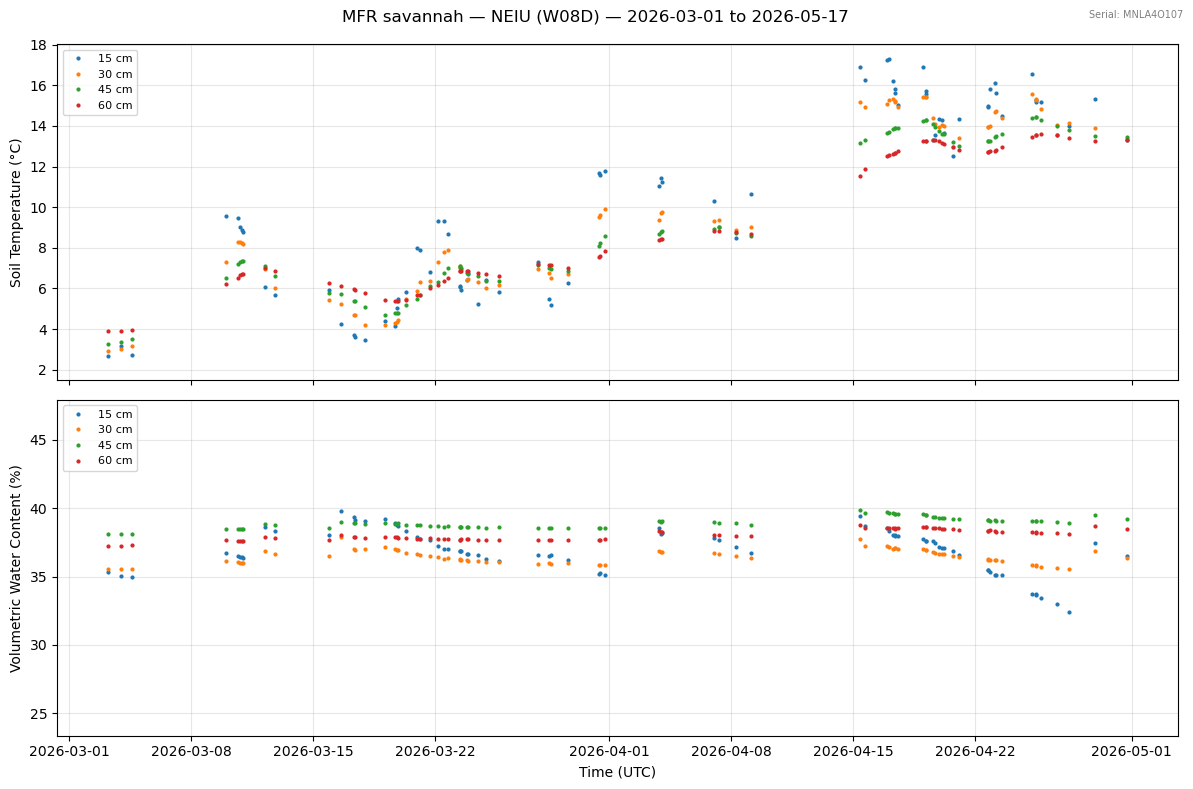

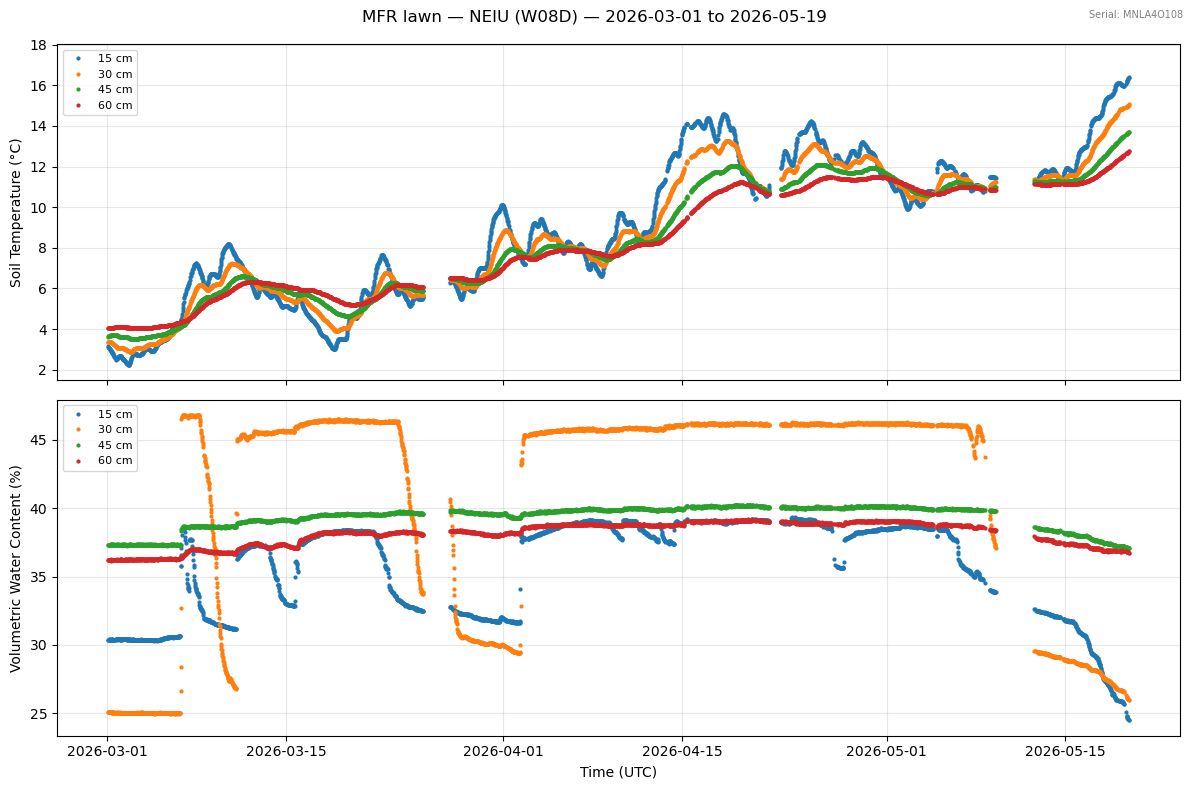

In [8]:
if mfr:
    # Compute common y-axis limits across all sites
    temp_min = min(df[['temp_15cm','temp_30cm','temp_45cm','temp_60cm']].min().min() 
                   for df in mfr.values())
    temp_max = max(df[['temp_15cm','temp_30cm','temp_45cm','temp_60cm']].max().max() 
                   for df in mfr.values())
    vwc_min  = min(df[['vwc_15cm','vwc_30cm','vwc_45cm','vwc_60cm']].min().min() 
                   for df in mfr.values())
    vwc_max  = max(df[['vwc_15cm','vwc_30cm','vwc_45cm','vwc_60cm']].max().max() 
                   for df in mfr.values())

    # Add a small margin
    temp_pad = (temp_max - temp_min) * 0.05
    vwc_pad  = (vwc_max  - vwc_min)  * 0.05

    for label, df in mfr.items():
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

        for col, depth in [('temp_15cm', '15 cm'), ('temp_30cm', '30 cm'),
                            ('temp_45cm', '45 cm'), ('temp_60cm', '60 cm')]:
            if col in df.columns:
                ax1.plot(df.index, df[col], linestyle='none', marker='o',
                         label=depth, markersize=2)
        ax1.set_ylim(temp_min - temp_pad, temp_max + temp_pad)
        ax1.set_ylabel('Soil Temperature (°C)')
        ax1.legend(loc='upper left', fontsize=8)
        ax1.grid(True, alpha=0.3)

        for col, depth in [('vwc_15cm', '15 cm'), ('vwc_30cm', '30 cm'),
                            ('vwc_45cm', '45 cm'), ('vwc_60cm', '60 cm')]:
            if col in df.columns:
                ax2.plot(df.index, df[col],
                         linestyle='none', marker='o', markersize=2,
                         label=depth)
        ax2.set_ylim(vwc_min - vwc_pad, vwc_max + vwc_pad)
        ax2.set_ylabel('Volumetric Water Content (%)')
        ax2.set_xlabel('Time (UTC)')
        ax2.legend(loc='upper left', fontsize=8)
        ax2.grid(True, alpha=0.3)

        fig.suptitle(f'MFR {label} — {SITE.abbr} ({SITE.vsn}) — {df.index.min().date()} to {df.index.max().date()}',
                     fontsize=12)
        # Add serial number as small annotation
        serial = next(k for k, v in SITE.mfr.items() if v['label'] == label)
        fig.text(0.99, 0.98, f'Serial: {serial}',
            ha='right', va='top',
            fontsize=7, color='0.5',
            transform=fig.transFigure)
        
        fig.tight_layout()
        plt.savefig(f'figures/mfr_{label}_soil.png', dpi=150, bbox_inches='tight')
        plt.show()

NB The savannah soil texture is mostly clay which may be responsible for saturation and the narrow range of VWC.

In [ ]:
# Simple soil statistics

if mfr:
    for label, df in mfr.items():
        print(f"\n{label}:")
        print(f"  Shape: {df.shape}")
        print(f"  Date range: {df.index.min()} to {df.index.max()}")
        print(f"\n  Column statistics:")
        cols = ['temp_15cm', 'temp_30cm', 'temp_45cm', 'temp_60cm',
                'vwc_15cm',  'vwc_30cm',  'vwc_45cm',  'vwc_60cm']
        for col in cols:
            if col in df.columns:
                valid = df[col].dropna()
                print(f"  {col:12}: n={len(valid):4d}  "
                      f"min={valid.min():7.2f}  "
                      f"max={valid.max():7.2f}  "
                      f"mean={valid.mean():7.2f}")

In [ ]:
# Check what RG-15 variables are available
df_rg15 = sage_data_client.query(
    start='-40d',
    filter={
        'vsn': 'W08D',
        'name': 'env.raingauge.*',
    }
)
print(f"Rows: {len(df_rg15)}")
print(f"Variables: {df_rg15['name'].unique()}")
print(df_rg15.head())